In [4]:
from torchvision import datasets , transforms

In [5]:
!pip install torch torchvision


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
transforms.ToTensor()

ToTensor()

In [7]:
transform = transforms.ToTensor()

In [8]:
train_dataset = datasets.MNIST(root = "./data" , train = True , download= True , transform = transform )

In [9]:
print(len(train_dataset))

60000


In [10]:
image , label = train_dataset[45]

print(image.shape)
print(label)

torch.Size([1, 28, 28])
9


## Let's display the image

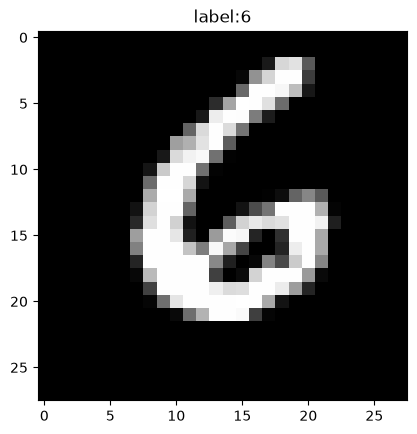

In [11]:
import matplotlib.pyplot as plt

image, label = train_dataset[90]

plt.imshow(image.squeeze(),cmap = "gray")
plt.title(f"label:{label}")
plt.show()

### We will use dataloader to get group of images in a batch 

In [12]:
from torch.utils.data import DataLoader

In [13]:
train_loader = DataLoader(train_dataset , batch_size= 64 , shuffle = True)

In [14]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [15]:
images = images.view(images.shape[0], -1)
print(images.shape)

torch.Size([64, 784])


### let's start building the model

In [16]:
import torch.nn as nn 

model = nn.Sequential(nn.Linear(784 , 128),
nn.ReLU() , 
nn.Linear(128,10))

In [17]:
images, labels = next(iter(train_loader))
images = images.view(images.shape[0], -1)

In [18]:
output = model(images)
print(output.shape)

torch.Size([64, 10])


In [23]:
print(output.shape)

torch.Size([64, 10])


In [22]:
print(output[0])

tensor([-0.0568, -0.1016, -0.0072, -0.0216,  0.0540,  0.0349, -0.0376,  0.0016,
        -0.1335,  0.0917], grad_fn=<SelectBackward0>)


In [25]:
criterion = nn.CrossEntropyLoss()

loss = criterion(output , labels )



In [26]:
print(loss)

tensor(2.3224, grad_fn=<NllLossBackward0>)
